<a href="https://colab.research.google.com/github/sudhamahalakshmi15-cell/Advance-time-series-forecasting/blob/main/cultusprojectga.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 0.1977 - val_loss: 0.0539
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0292 - val_loss: 0.0376
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0134 - val_loss: 0.0244
Epoch 4/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0090 - val_loss: 0.0348
Epoch 5/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0057 - val_loss: 0.0279
Epoch 6/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0043 - val_loss: 0.0129
Epoch 7/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0040 - val_loss: 0.0128
Epoch 8/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0034 - val_loss: 0.0091
Epoch 9/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0024 - val_loss: 0.0041
Epoch 10/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0021 - val_loss: 0.0040
Epoch 11/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0022 - val_loss: 0.0036
Epoch 12/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0020 - val_l

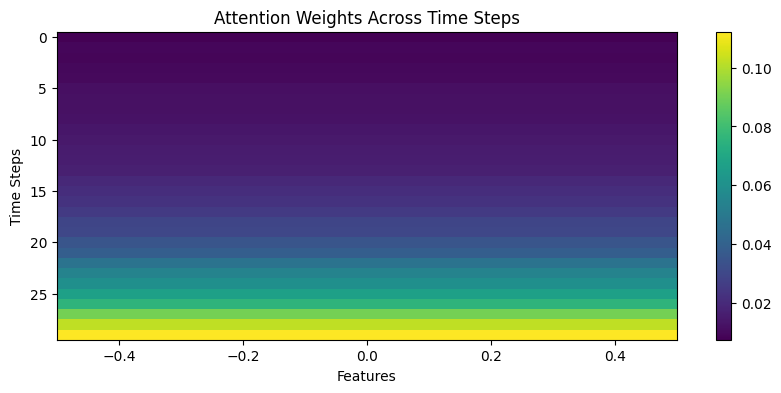

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# -----------------------------
# 1. Generate Multivariate Time Series Data
# -----------------------------
np.random.seed(42)

time_steps = 1500
t = np.arange(time_steps)

data = pd.DataFrame({
    "sensor_1": np.sin(0.02 * t) + np.random.normal(0, 0.1, time_steps),
    "sensor_2": np.cos(0.015 * t) + np.random.normal(0, 0.1, time_steps),
    "sensor_3": 0.5 * np.sin(0.01 * t) + np.random.normal(0, 0.1, time_steps),
    "sensor_4": np.random.normal(0, 0.2, time_steps),
    "sensor_5": 0.01 * t + np.random.normal(0, 0.2, time_steps)
})

target = data["sensor_1"].values.reshape(-1, 1)

# -----------------------------
# 2. Scaling
# -----------------------------
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_x.fit_transform(data)
y_scaled = scaler_y.fit_transform(target)

# -----------------------------
# 3. Sequence Creation
# -----------------------------
def create_sequences(X, y, input_len=30, output_len=5):
    Xs, ys = [], []
    for i in range(len(X) - input_len - output_len):
        Xs.append(X[i:i+input_len])
        ys.append(y[i+input_len:i+input_len+output_len])
    return np.array(Xs), np.array(ys)

INPUT_LEN = 30
OUTPUT_LEN = 5

X_seq, y_seq = create_sequences(X_scaled, y_scaled, INPUT_LEN, OUTPUT_LEN)

split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

# -----------------------------
# 4. Attention Layer
# -----------------------------
class AttentionLayer(layers.Layer):
    def _init_(self):
        super()._init_()

    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], input_shape[-1]),
                                 initializer="random_normal",
                                 trainable=True)
        self.b = self.add_weight(shape=(input_shape[-1],),
                                 initializer="zeros",
                                 trainable=True)
        self.u = self.add_weight(shape=(input_shape[-1], 1),
                                 initializer="random_normal",
                                 trainable=True)

    def call(self, inputs):
        score = tf.nn.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        attention_weights = tf.nn.softmax(tf.tensordot(score, self.u, axes=1), axis=1)
        context_vector = attention_weights * inputs
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector, attention_weights

# -----------------------------
# 5. Encoder–Decoder Model with Attention
# -----------------------------
encoder_inputs = layers.Input(shape=(INPUT_LEN, X_train.shape[2]))
encoder_lstm = layers.LSTM(64, return_sequences=True)(encoder_inputs)

attention_out, attention_weights = AttentionLayer()(encoder_lstm)

decoder_output = layers.RepeatVector(OUTPUT_LEN)(attention_out)
decoder_lstm = layers.LSTM(64, return_sequences=True)(decoder_output)
final_output = layers.TimeDistributed(layers.Dense(1))(decoder_lstm)

attention_model = models.Model(encoder_inputs, final_output)
attention_model.compile(
    optimizer="adam",
    loss="mse"
)

# -----------------------------
# 6. Baseline LSTM (No Attention)
# -----------------------------
baseline_model = models.Sequential([
    layers.LSTM(64, input_shape=(INPUT_LEN, X_train.shape[2])),
    layers.RepeatVector(OUTPUT_LEN),
    layers.LSTM(64, return_sequences=True),
    layers.TimeDistributed(layers.Dense(1))
])

baseline_model.compile(optimizer="adam", loss="mse")

# -----------------------------
# 7. Training
# -----------------------------
attention_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

baseline_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# -----------------------------
# 8. Evaluation
# -----------------------------
def evaluate(model, X, y):
    preds = model.predict(X)
    preds = scaler_y.inverse_transform(preds.reshape(-1, 1))
    y_true = scaler_y.inverse_transform(y.reshape(-1, 1))
    mae = mean_absolute_error(y_true, preds)
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    mape = np.mean(np.abs((y_true - preds) / y_true)) * 100
    return mae, rmse, mape

att_mae, att_rmse, att_mape = evaluate(attention_model, X_test, y_test)
base_mae, base_rmse, base_mape = evaluate(baseline_model, X_test, y_test)

print("\n--- Model Comparison ---")
print(f"Attention Model -> MAE:{att_mae:.4f}, RMSE:{att_rmse:.4f}, MAPE:{att_mape:.2f}%")
print(f"Baseline Model  -> MAE:{base_mae:.4f}, RMSE:{base_rmse:.4f}, MAPE:{base_mape:.2f}%")

# -----------------------------
# 9. Attention Weight Visualization
# -----------------------------
attention_extractor = models.Model(
    inputs=attention_model.input,
    outputs=attention_weights
)

weights = attention_extractor.predict(X_test[:1])[0]

plt.figure(figsize=(10, 4))
plt.imshow(weights, aspect="auto", cmap="viridis")
plt.colorbar()
plt.title("Attention Weights Across Time Steps")
plt.xlabel("Features")
plt.ylabel("Time Steps")
plt.show()